In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Импортируем твои алгоритмы (убедись, что __init__.py есть в папке algos, 
# либо просто добавь путь в sys.path)
from algos import fuzzy, oracle, broumi, moghanni, montemanni, xu

# Настройка визуализации
%matplotlib inline
plt.style.use('seaborn-v0_8') # или другой стиль по вкусу

print("Окружение готово к работе!")

Окружение готово к работе!


In [34]:
# Посмотрим список файлов в датасете
dataset_path = 'dataset/'
files = os.listdir(dataset_path)
print(f"Файлы в датасете: {files}")

# Давай загрузим один для примера (замени 'example.csv' на реальное имя файла)
df_sample = pd.read_csv(os.path.join(dataset_path, files[0]))
df_sample.head()

Файлы в датасете: ['graph_0001_n43.txt', 'graph_0002_n20.txt', 'graph_0003_n9.txt', 'graph_0004_n74.txt', 'graph_0005_n85.txt', 'graph_0006_n98.txt', 'graph_0007_n3.txt', 'graph_0008_n58.txt', 'graph_0009_n17.txt', 'graph_0010_n61.txt', 'graph_0011_n80.txt', 'graph_0012_n64.txt', 'graph_0013_n48.txt', 'graph_0014_n39.txt', 'graph_0015_n91.txt', 'graph_0016_n65.txt', 'graph_0017_n44.txt', 'graph_0018_n51.txt', 'graph_0019_n24.txt', 'graph_0020_n19.txt', 'graph_0021_n9.txt', 'graph_0022_n6.txt', 'graph_0023_n84.txt', 'graph_0024_n45.txt', 'graph_0025_n39.txt', 'graph_0026_n69.txt', 'graph_0027_n49.txt', 'graph_0028_n66.txt', 'graph_0029_n25.txt', 'graph_0030_n98.txt', 'graph_0031_n56.txt', 'graph_0032_n55.txt', 'graph_0033_n95.txt', 'graph_0034_n33.txt', 'graph_0035_n94.txt', 'graph_0036_n86.txt', 'graph_0037_n94.txt', 'graph_0038_n46.txt', 'graph_0039_n4.txt', 'graph_0040_n66.txt', 'graph_0041_n33.txt', 'graph_0042_n87.txt', 'graph_0043_n33.txt', 'graph_0044_n33.txt', 'graph_0045_n83.tx

,43 99
0,0 13 60 61 61
1,0 37 81 94 93
2,0 21 80 89 82
3,0 6 47 67 66
4,13 8 78 98 91


In [35]:
import glob
import os
import pandas as pd

results_path = 'results/'
all_files = glob.glob(os.path.join(results_path, "*.csv"))

# Читаем первый файл
main_df = pd.read_csv(all_files[0])

def clean_columns(df, file_name):
    # Извлекаем чистое имя алгоритма из названия файла
    alg_name = os.path.basename(file_name).replace('_results.csv', '').replace('_costs.csv', '')
    
    new_cols = {}
    for col in df.columns:
        if col == 'graph_file':
            continue
            
        # Убираем повторы, если имя алгоритма уже есть в названии колонки
        clean_col = col.replace(f"{alg_name}_", "")
        new_cols[col] = f"{alg_name}_{clean_col}"
        
    return df.rename(columns=new_cols)

# Обрабатываем первый файл
main_df = clean_columns(main_df, all_files[0])

# Присоединяем остальные
for file in all_files[1:]:
    current_df = pd.read_csv(file)
    current_df = clean_columns(current_df, file)
    
    # Объединяем по graph_file
    main_df = pd.merge(main_df, current_df, on='graph_file', how='inner')

# Выводим список колонок, чтобы убедиться, что всё красиво
print("Список колонок после объединения:")
print(main_df.columns.tolist())
main_df.head()

Список колонок после объединения:
['graph_file', 'broumi_execution_time_ms', 'broumi_cost_real', 'broumi_path_length', 'fuzzy_execution_time_ms', 'fuzzy_cost_real', 'fuzzy_path_length', 'moghanni_execution_time_ms', 'moghanni_cost_real', 'moghanni_path_length', 'montemanni_execution_time_ms', 'montemanni_cost_real', 'montemanni_path_length', 'oracle_num_nodes', 'oracle_ideal_cost_real', 'oracle_ideal_path_length', 'xu_execution_time_ms', 'xu_cost_real', 'xu_path_length']


,graph_file,broumi_execution_time_ms,broumi_cost_real,broumi_path_length,fuzzy_execution_time_ms,fuzzy_cost_real,fuzzy_path_length,moghanni_execution_time_ms,moghanni_cost_real,moghanni_path_length,montemanni_execution_time_ms,montemanni_cost_real,montemanni_path_length,oracle_num_nodes,oracle_ideal_cost_real,oracle_ideal_path_length,xu_execution_time_ms,xu_cost_real,xu_path_length
0,graph_0001_n43.txt,0.1285,198,3,0.0653,198,3,0.1785,198,3,9.0289,198.0,3,43,198,3,0.0975,198,3
1,graph_0002_n20.txt,0.0129,59,1,0.0092,59,1,0.0119,59,1,6.3377,59.0,1,20,59,1,0.0138,59,1
2,graph_0003_n9.txt,0.0091,53,1,0.0077,53,1,0.0222,53,1,4.1309,53.0,1,9,53,1,0.0072,53,1
3,graph_0004_n74.txt,0.0203,111,2,0.0125,111,2,0.0176,111,2,13.0102,111.0,2,74,111,2,0.0120,111,2
4,graph_0005_n85.txt,0.0174,70,1,0.0055,70,1,0.0083,70,1,10.3935,70.0,1,85,70,1,0.0044,70,1


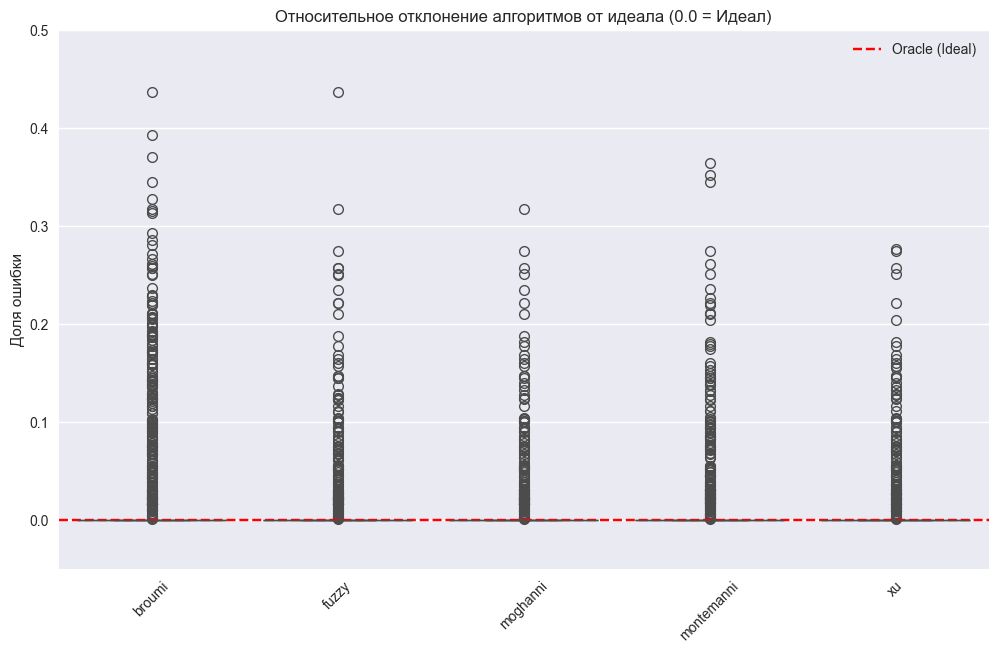

In [36]:
# 1. Считаем относительную ошибку для каждого алгоритма
oracle_col = 'oracle_ideal_cost_real'
error_df = pd.DataFrame()

# Выбираем только колонки со стоимостью, исключая сам оракул
cost_cols = [col for col in main_df.columns if 'cost_real' in col and col != oracle_col]

for col in cost_cols:
    alg_name = col.replace('_cost_real', '')
    # Относительная ошибка: (Алгоритм - Оракул) / Оракул
    error_df[alg_name] = (main_df[col] - main_df[oracle_col]) / main_df[oracle_col]

# 2. Строим Boxplot для ошибок (ограничим y, чтобы выбросы Montemanni не мешали)
plt.figure(figsize=(12, 7))
sns.boxplot(data=error_df)
plt.ylim(-0.05, 0.5) # Показываем отклонение от -5% до +20%
plt.axhline(y=0, color='r', linestyle='--', label='Oracle (Ideal)')
plt.title("Относительное отклонение алгоритмов от идеала (0.0 = Идеал)")
plt.ylabel("Доля ошибки")
plt.xticks(rotation=45)
plt.legend()
plt.show()

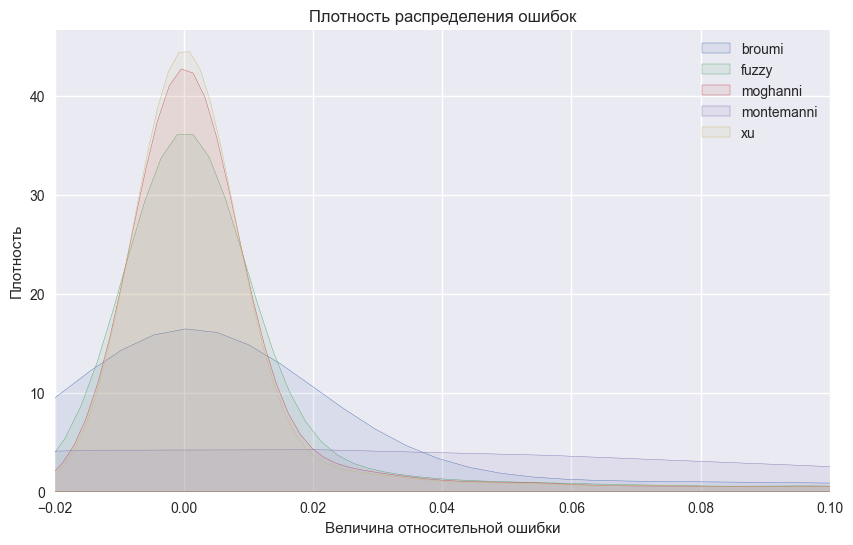

In [37]:
plt.figure(figsize=(10, 6))

for col in error_df.columns:
    # Строим график распределения плотности ошибки
    sns.kdeplot(error_df[col], label=col, fill=True, alpha=0.1)

plt.xlim(-0.02, 0.1) # Фокусируемся на зоне малой ошибки
plt.title("Плотность распределения ошибок")
plt.xlabel("Величина относительной ошибки")
plt.ylabel("Плотность")
plt.legend()
plt.show()

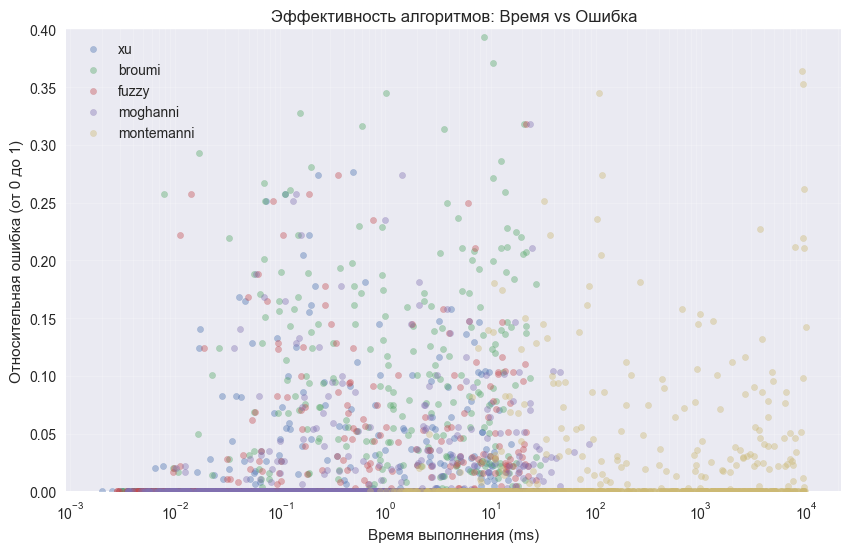

In [38]:
plt.figure(figsize=(10, 6))
algs = ['xu', 'broumi', 'fuzzy', 'moghanni', 'montemanni']

for alg in algs:
    # Используем правильное имя колонки из твоего списка
    time_col = f'{alg}_execution_time_ms'
    if time_col in main_df.columns:
        plt.scatter(main_df[time_col], error_df[alg], alpha=0.4, label=alg, s=20)

plt.xscale('log') # Логарифмическая шкала, если разброс времени большой
plt.xlabel('Время выполнения (ms)')
plt.ylabel('Относительная ошибка (от 0 до 1)')
plt.ylim(0, 0.4) # Фокусируемся на зоне малой ошибки
plt.title('Эффективность алгоритмов: Время vs Ошибка')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

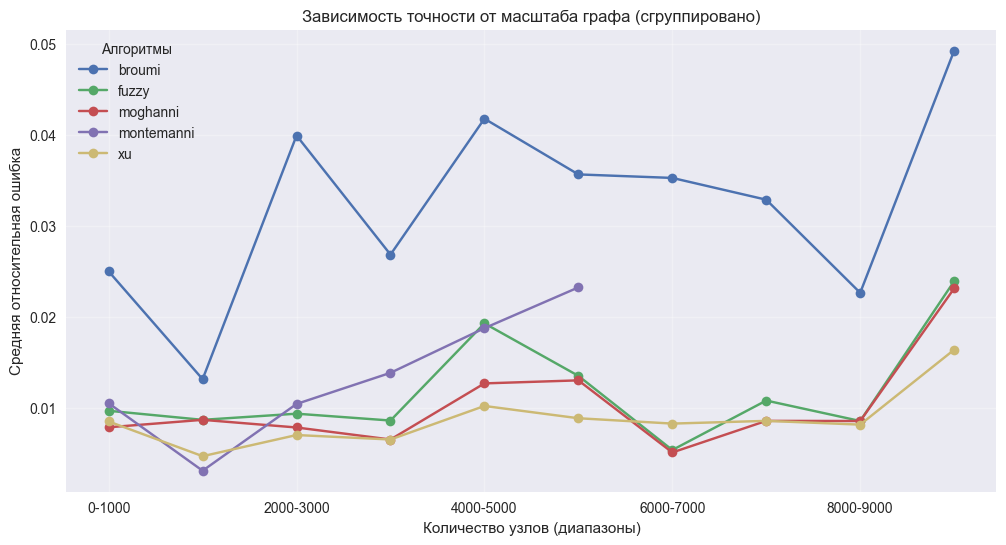

In [39]:
# Создаем интервалы по 1000 узлов
main_df['node_range'] = pd.cut(main_df['oracle_num_nodes'], 
                               bins=range(0, 11000, 1000), 
                               labels=[f'{i}-{i+1000}' for i in range(0, 10000, 1000)])

# Считаем среднюю ошибку для каждого диапазона
binned_error = error_df.copy()
binned_error['node_range'] = main_df['node_range']
plot_data = binned_error.groupby('node_range').mean()

plt.figure(figsize=(12, 6))
plot_data.plot(kind='line', marker='o', ax=plt.gca())

plt.title("Зависимость точности от масштаба графа (сгруппировано)")
plt.xlabel("Количество узлов (диапазоны)")
plt.ylabel("Средняя относительная ошибка")
plt.grid(True, alpha=0.3)
plt.legend(title="Алгоритмы")
plt.show()

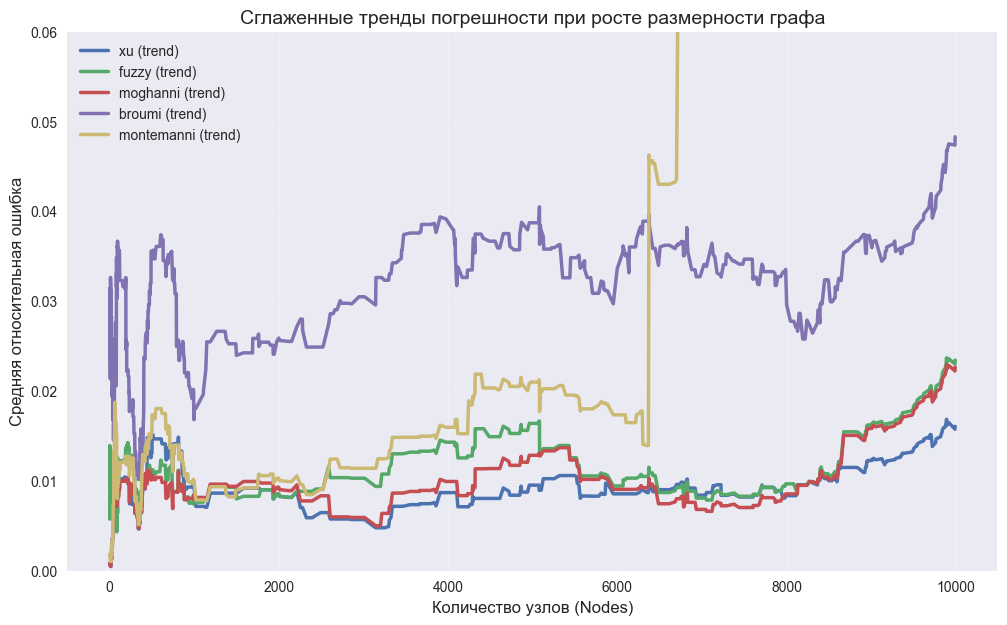

In [40]:
plt.figure(figsize=(12, 7))

# Список алгоритмов для сравнения (уберем montemanni из-за пропусков)
algs_to_compare = ['xu', 'fuzzy', 'moghanni', 'broumi', 'montemanni']

# Создаем копию для сортировки
trend_df = error_df[algs_to_compare].copy()
trend_df['nodes'] = main_df['oracle_num_nodes']
trend_df = trend_df.sort_values('nodes')

for alg in algs_to_compare:
    # window=50 — это размер окна сглаживания. 
    # Если линия слишком "дерганая", увеличь до 100.
    smooth_val = trend_df[alg].rolling(window=100, center=True, min_periods=1).mean()
    
    plt.plot(trend_df['nodes'], smooth_val, label=f'{alg} (trend)', linewidth=2.5)

plt.ylim(0, 0.06) # Ограничим до 6%, чтобы увидеть детали
plt.title("Сглаженные тренды погрешности при росте размерности графа", fontsize=14)
plt.xlabel("Количество узлов (Nodes)", fontsize=12)
plt.ylabel("Средняя относительная ошибка", fontsize=12)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

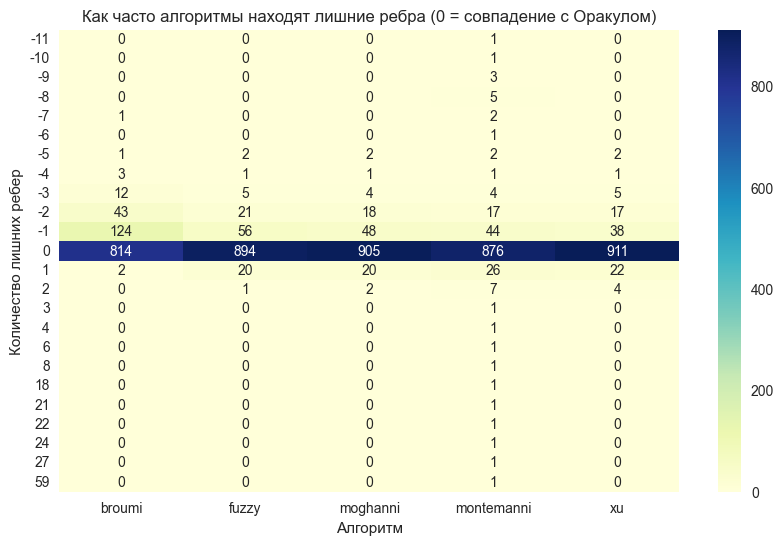

In [41]:
# 1. Считаем разницу в количестве ребер
path_delta_df = pd.DataFrame()
oracle_path = 'oracle_ideal_path_length'

path_cols = [col for col in main_df.columns if 'path_length' in col and col != oracle_path]

for col in path_cols:
    alg_name = col.replace('_path_length', '')
    # Считаем абсолютную разницу: сколько лишних ребер добавил алгоритм
    path_delta_df[alg_name] = main_df[col] - main_df[oracle_path]

# 2. Визуализация через Heatmap или Countplot
plt.figure(figsize=(10, 6))
sns.heatmap(path_delta_df.apply(pd.Series.value_counts).fillna(0), 
            annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Как часто алгоритмы находят лишние ребра (0 = совпадение с Оракулом)")
plt.xlabel("Алгоритм")
plt.ylabel("Количество лишних ребер")
plt.show()

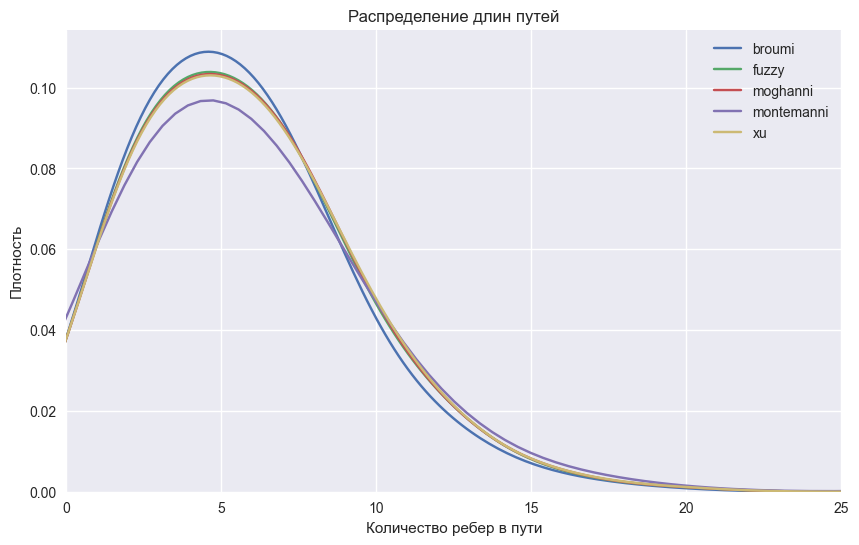

In [42]:
plt.figure(figsize=(10, 6))

for col in path_cols:
    alg_name = col.replace('_path_length', '')
    sns.kdeplot(main_df[col], label=alg_name, bw_adjust=2)

plt.xlim(0, 25) # Ограничим до 25 ребер, чтобы не видеть аномалии Montemanni
plt.title("Распределение длин путей")
plt.xlabel("Количество ребер в пути")
plt.ylabel("Плотность")
plt.legend()
plt.show()

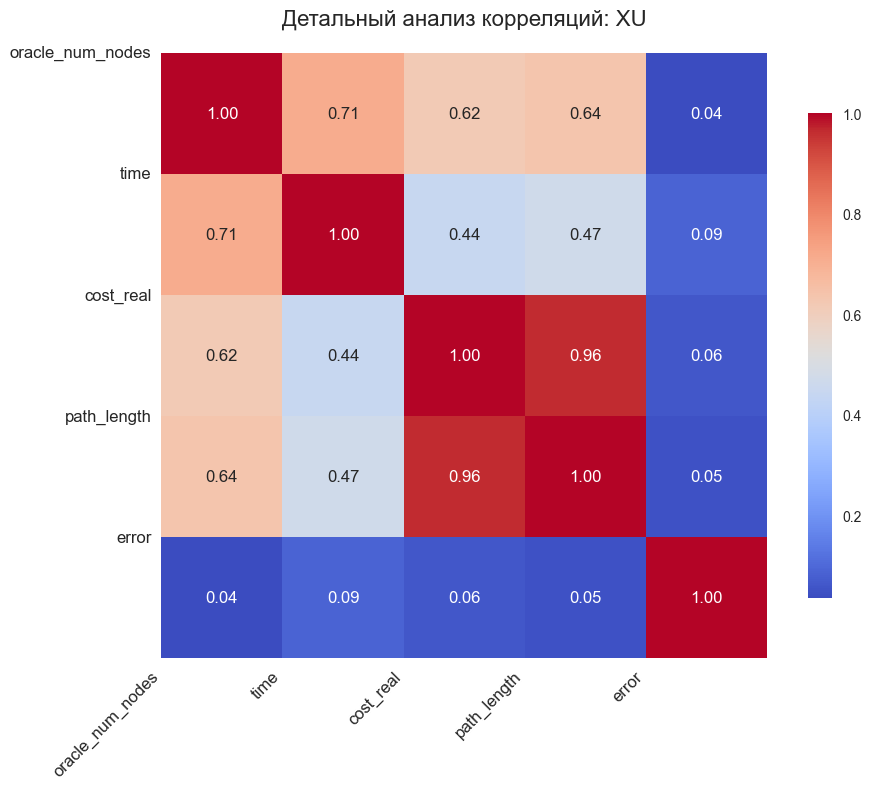

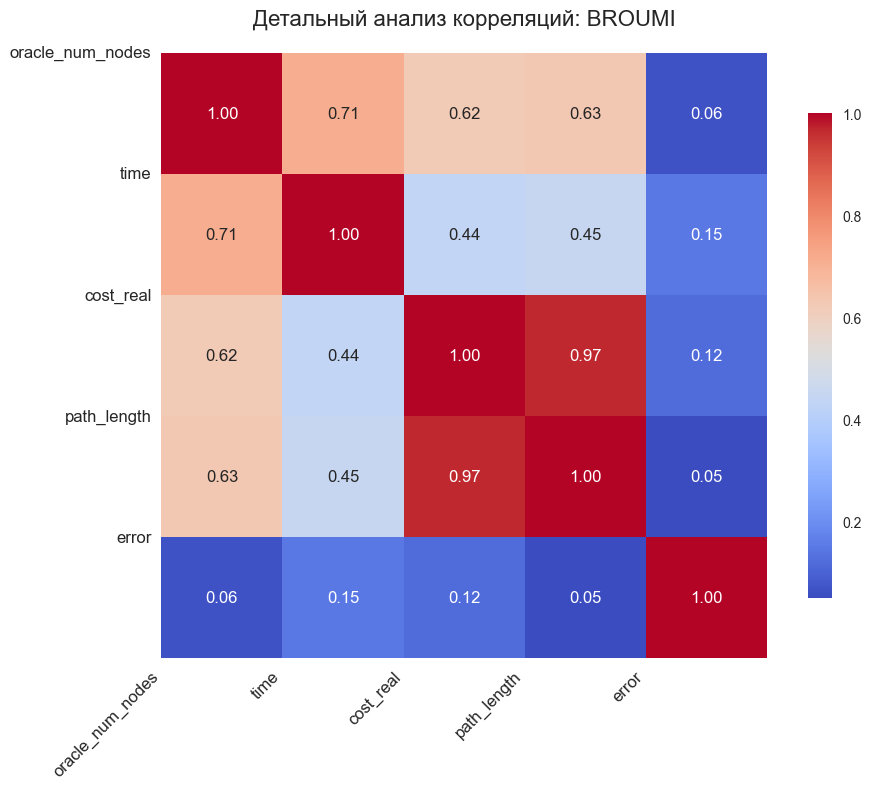

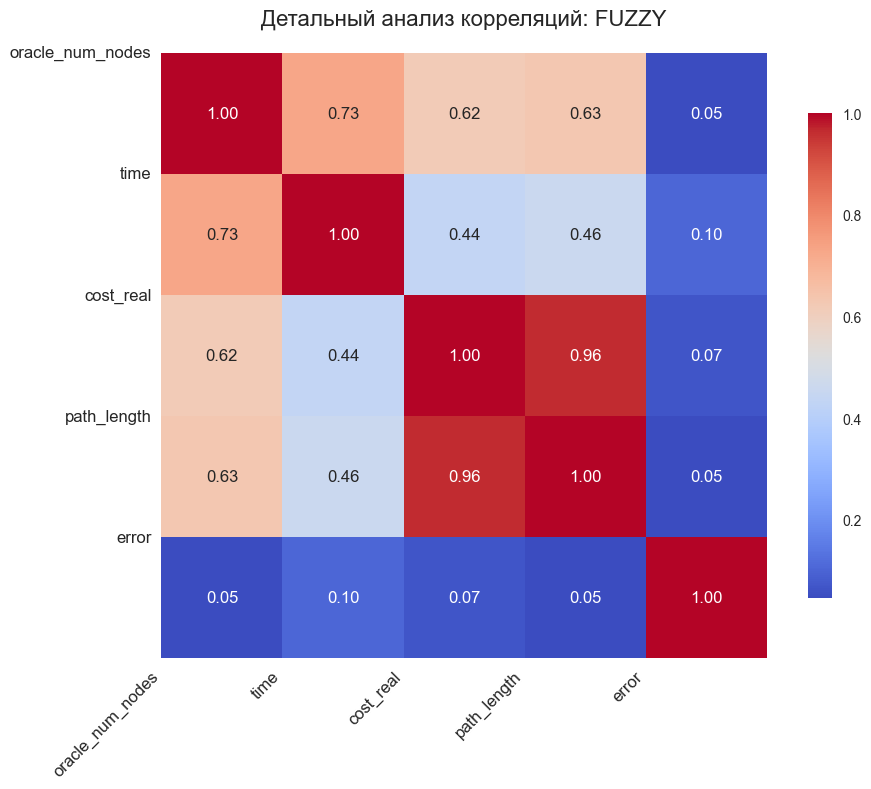

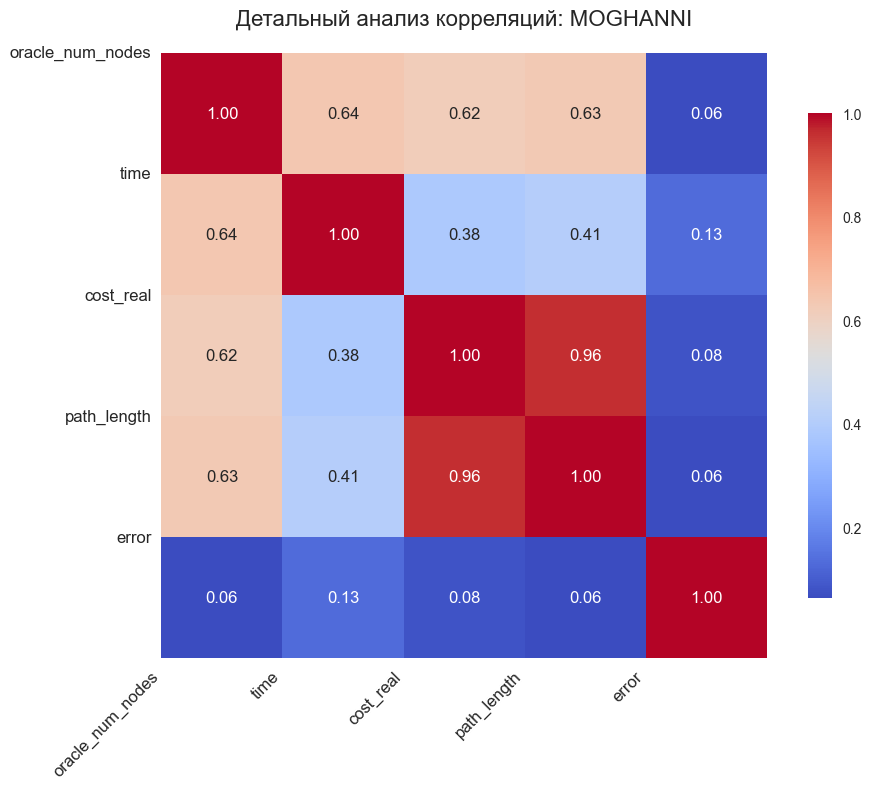

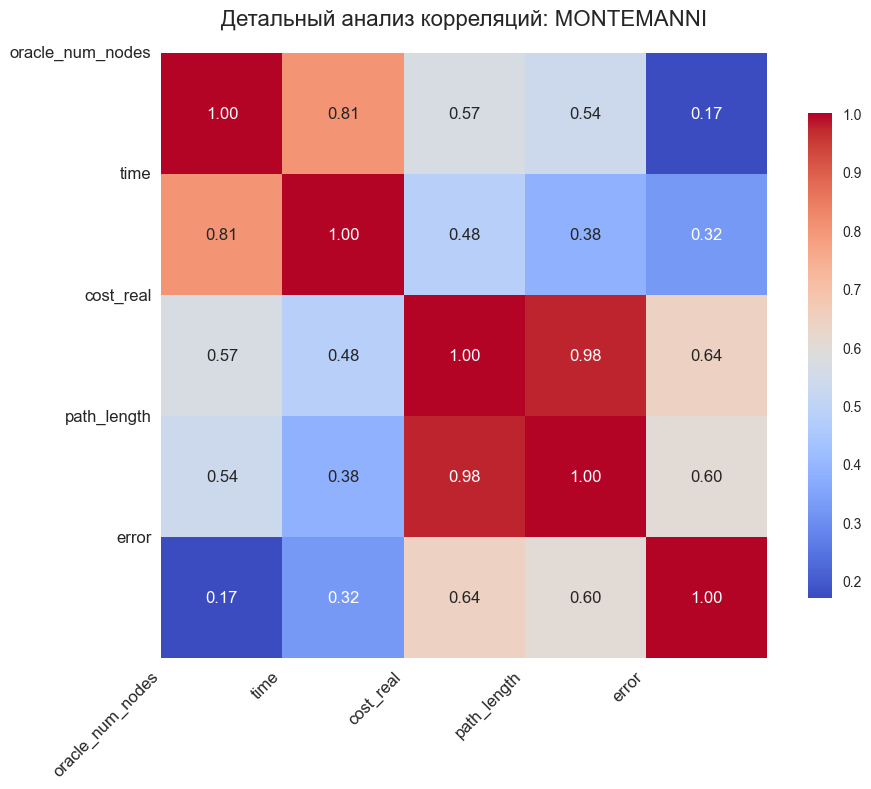

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

algorithms = ['xu', 'broumi', 'fuzzy', 'moghanni', 'montemanni']

for alg in algorithms:
    # Собираем данные
    cols = ['oracle_num_nodes', f'{alg}_execution_time_ms', f'{alg}_cost_real', f'{alg}_path_length']
    existing_cols = [c for c in cols if c in main_df.columns]
    
    if existing_cols:
        temp_corr_data = main_df[existing_cols].copy()
        temp_corr_data[f'{alg}_error'] = error_df[alg]
        
        # Считаем корреляцию
        corr_matrix = temp_corr_data.corr()
        
        # Создаем фигуру большого размера
        plt.figure(figsize=(10, 8))
        
        # Рисуем карту с крупными шрифтами
        sns.heatmap(corr_matrix, 
                    annot=True, 
                    cmap='coolwarm', 
                    fmt=".2f", 
                    annot_kws={"size": 12}, # Размер цифр внутри
                    square=True, 
                    cbar_kws={"shrink": .8})
        
        # Чистим названия для красоты
        clean_labels = [l.replace(f'{alg}_', '').replace('execution_', '').replace('_ms', '') for l in corr_matrix.columns]
        plt.xticks(range(len(clean_labels)), clean_labels, rotation=45, ha='right', fontsize=12)
        plt.yticks(range(len(clean_labels)), clean_labels, rotation=0, fontsize=12)
        
        plt.title(f"Детальный анализ корреляций: {alg.upper()}", fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

In [45]:
import numpy as np
import pandas as pd

# Список алгоритмов
algs = ['xu', 'broumi', 'fuzzy', 'moghanni', 'montemanni']
summary_stats = []

for alg in algs:
    # 1. Попадания и Ошибки
    exact_hits = (error_df[alg].abs() < 1e-6).sum()
    hit_rate = (exact_hits / len(error_df)) * 100
    
    # Исключаем бесконечности для расчета средних
    clean_errors = error_df[alg].replace([np.inf, -np.inf], np.nan).dropna()
    avg_miss_err = clean_errors[clean_errors > 1e-6].mean() * 100
    max_err = clean_errors.max() * 100
    
    # 2. Структурная точность (путь по ребрам)
    # Считаем, сколько раз длина пути совпала с идеальной от Оракула
    struct_hits = (main_df[f'{alg}_path_length'] == main_df['oracle_ideal_path_length']).sum()
    struct_acc = (struct_hits / len(main_df)) * 100
    
    # 3. Скорость (микросекунды на узел)
    # Берем время в мс, переводим в мкс (*1000) и делим на кол-во узлов
    time_per_node = (main_df[f'{alg}_execution_time_ms'] * 1000 / main_df['oracle_num_nodes']).mean()
    
    summary_stats.append({
        'Алгоритм': alg.upper(),
        'Попаданий в цель (%)': round(hit_rate, 2),
        'Ошибка при промахе (%)': round(avg_miss_err, 2),
        'Макс. ошибка (%)': round(max_err, 2),
        'Совпадение по ребрам (%)': round(struct_acc, 2),
        'Мкс на 1 узел (µs/node)': round(time_per_node, 3)
    })

# Создаем и выводим финальную таблицу
full_stats_df = pd.DataFrame(summary_stats).set_index('Алгоритм')
display(full_stats_df)

,Попаданий в цель (%),Ошибка при промахе (%),Макс. ошибка (%),Совпадение по ребрам (%),Мкс на 1 узел (µs/node)
Алгоритм,,,,,
XU,86.3,6.36,27.67,91.1,0.597
BROUMI,76.5,12.07,85.71,81.4,0.915
FUZZY,84.3,6.85,43.75,89.4,0.862
MOGHANNI,85.5,6.24,31.77,90.5,1.255
MONTEMANNI,81.4,22.04,654.72,87.6,295.703
